In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import specula
specula.init(0)

from scipy.ndimage import rotate
from specula.data_objects.ifunc import IFunc
from specula.data_objects.ifunc_inv import IFuncInv


2026-07-03 09:53:12,435 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-03 09:53:12,556 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
def show2d_slopes(slopes,npix=120,normalize:bool=False,title='',vmin=None,vmax=None,show=True,ppath='pyr_pupdata_40x40'):
    if normalize:
        slopes -= np.mean(slopes)
        slopes_rms = np.std(slopes)
        slopes /= slopes_rms

    filepath=f'/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/{ppath}.fits'
    pup_hdu = fits.open(filepath)
    pup_ids = pup_hdu[1].data
    fimg = np.zeros(npix**2)
    np.put(fimg, pup_ids[:,0], slopes[:len(slopes)//2])
    np.put(fimg, pup_ids[:,1], slopes[len(slopes)//2:])
    f2d = fimg.reshape([npix,npix])

    if vmin is None:
        vmin = np.min(f2d)
    if vmax is None:
        vmax = np.max(f2d)
    
    if show:
        plt.figure()
        plt.imshow(np.ma.masked_array(f2d,mask=np.abs(f2d)==0),origin='lower',cmap='RdBu',vmin=vmin,vmax=vmax)
        plt.ylim([12,60])
        plt.xlim([12,108])
        plt.axis('off')
        plt.title(title)
        plt.colorbar(shrink=0.5)
    return f2d


In [4]:
klinv = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_kl_inv.fits')
kl = np.linalg.pinv(klinv)
lbtpup = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/pupilstop/asm_v32sx_198pixels.fits')
ifunc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_ifunc.fits')

In [173]:
rot = -145
ifunc_new = np.zeros(ifunc.shape)
kl_new = np.zeros(kl.shape)
img = np.zeros(lbtpup.shape)
for j in range(ifunc.shape[1]):
    img[lbtpup.astype(bool)] = ifunc[:,j]
    rot_img = rotate(img,angle=rot,reshape=False)
    rot_flip_img = rot_img[::-1,:]
    ifunc_new[:,j] = rot_flip_img[lbtpup.astype(bool)]
ifunc_obj = IFunc(ifunc=ifunc_new.T,mask=lbtpup)
ifunc_obj.save('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_ifunc_shift.fits', overwrite=True)

for j in range(kl.shape[1]):
    img[lbtpup.astype(bool)] = kl[:,j]
    rot_img = rotate(img,angle=rot,reshape=False)    
    rot_flip_img = rot_img[::-1,:]
    kl_new[:,j] = rot_flip_img[lbtpup.astype(bool)]
kl_inv_new = np.linalg.pinv(kl_new.T)
ifunc_inv_obj = IFuncInv(ifunc_inv=kl_inv_new,mask=lbtpup)
ifunc_inv_obj.save('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_ifunc_shift_inv.fits', overwrite=True)

(30117, 600)


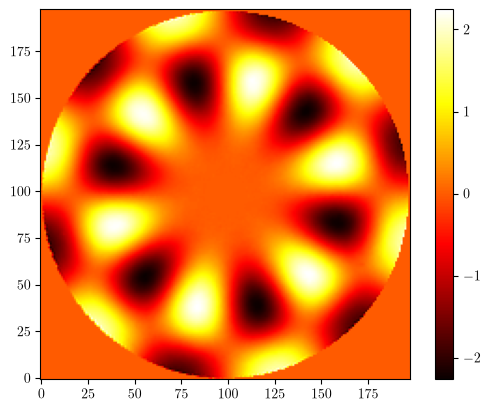

In [160]:
print(kl.shape)

idx = 40
img = np.zeros(lbtpup.shape)
img[lbtpup.astype(bool)] = kl_new[:,idx]

plt.figure()
plt.imshow(img,origin='lower')
plt.colorbar()

In [72]:
# im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/data/Intmat_20250509_183420.fits')
# rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/data/Rec_20250509_183420.fits')
# print(im.shape,rec.shape)

# plt.figure()
# plt.loglog(np.arange(500)+1, np.diag(rec @ im))

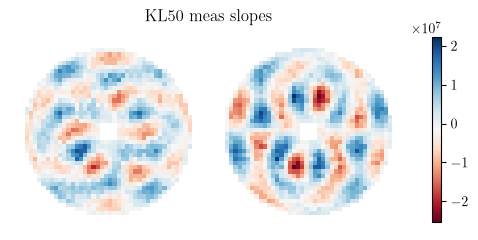

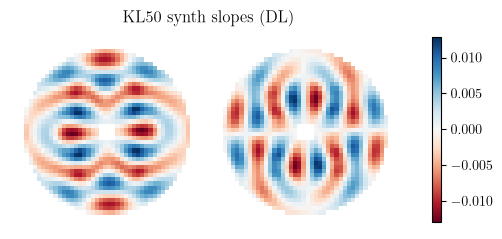

In [177]:
pyr_masks = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/lbt_pupmask_shift.fits').astype(bool)
aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/im/pyr3.0_40x40_lbt_synim.fits') #pyr3.0_40x40_shift_im.fits') #
optsynim = aux.copy()
optsynim[:2512//2,:] = aux[2512//2:,:]*-1
optsynim[2512//2:,:] = aux[:2512//2,:]

tempim = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/data/Intmat_20250509_183420.fits')[:2512,:]
pupids = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pup_ids.fits')

half_mask = pyr_masks[:60,:120].astype(bool)
idx = 50
img = np.zeros(np.size(half_mask))
img[half_mask.flatten()] = tempim[pupids,idx]
img = img.reshape([60,120])

plt.figure()
plt.imshow(np.ma.masked_array(img,mask=img==0),origin='lower',cmap='RdBu')
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(f'KL{idx} meas slopes')

f2dopt=show2d_slopes(optsynim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (DL)')

55.38573924417881 -0.8478146515476562 -0.6275266973101545 1.0027714255905495


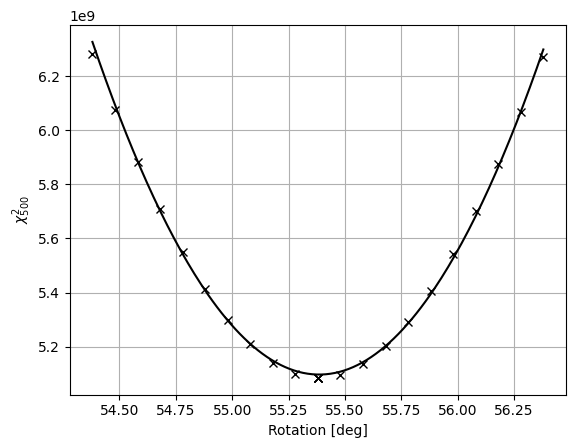

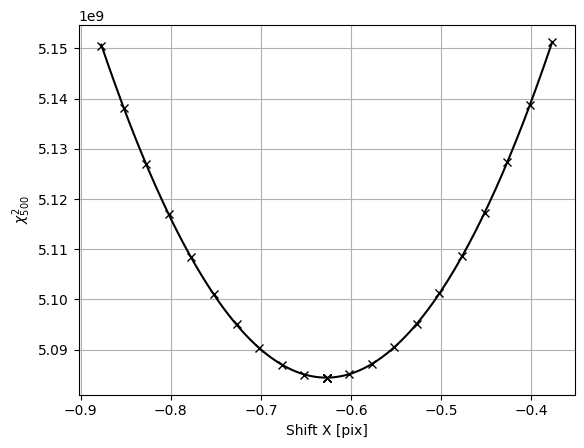

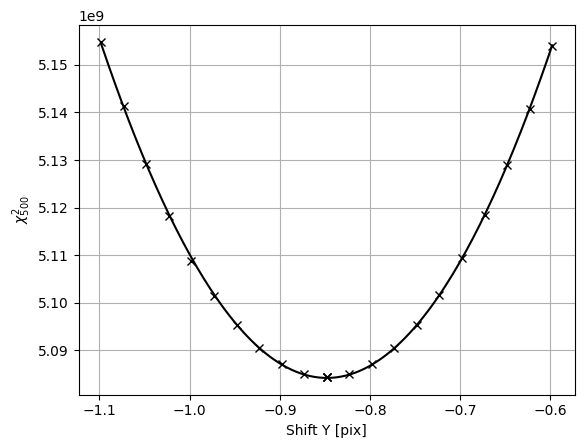

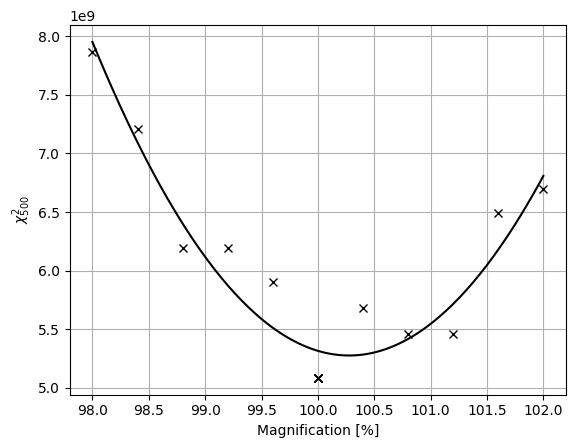

In [ ]:
import pandas as pd

df_tot = pd.read_csv('/raid1/mmenessini/results/SOUL/KLv32sx/misreg_csv/it3_deltaRot0.10_deltaShift0.02_deltaMag0.36_metric.csv') #

df = df_tot[df_tot['magnification']==1.0]

df_rot = df['rotation']
df_shftX = df['shiftX']
df_shftY = df['shiftY']

dX0 = -0.627
dY0 = -0.848
Rot0 = 55.38

dfvRot = df[np.logical_and(df_shftX==dX0,df_shftY==dY0)]
skip = 2
prot = np.polyfit(dfvRot['rotation'][skip:-skip-1],dfvRot['metric'][skip:-skip-1],2) #
x = np.linspace(np.min(dfvRot['rotation']),np.max(dfvRot['rotation']),200)
plt.figure()
plt.plot(dfvRot['rotation'],dfvRot['metric'],'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(prot,x),c='k')
plt.xlabel('Rotation [deg]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()


dfvdX = df[np.logical_and(df_rot==Rot0,df_shftY==dY0)]
psX = np.polyfit(dfvdX['shiftX'],dfvdX['metric'],2)
x = np.linspace(np.min(dfvdX['shiftX']),np.max(dfvdX['shiftX']),200)
plt.figure()
plt.plot(dfvdX['shiftX'],dfvdX['metric'],'x',c='k')
plt.plot(x,np.polyval(psX,x),c='k')
plt.xlabel('Shift X [pix]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()

dfvdY = df[np.logical_and(df_rot==Rot0,df_shftX==dX0)]
psY = np.polyfit(dfvdY['shiftY'][:-1],dfvdY['metric'][:-1],2)
x = np.linspace(np.min(dfvdY['shiftY']),np.max(dfvdY['shiftY']),200)
plt.figure()
plt.plot(dfvdY['shiftY'][:-1],dfvdY['metric'][:-1],'x',c='k')
plt.plot(x,np.polyval(psY,x),c='k')
plt.xlabel('Shift Y [pix]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()


dfMag = df_tot[np.logical_and(np.logical_and(df_tot['shiftX']==dX0,df_tot['shiftY']==dY0),df_tot['rotation']==Rot0)]
pMag = np.polyfit(dfMag['magnification'],dfMag['metric'],2)
x = np.linspace(np.min(dfMag['magnification']),np.max(dfMag['magnification']),200)
plt.figure()
plt.plot(dfMag['magnification']*1e+2,dfMag['metric'],'x',c='k')
plt.plot(x*1e+2,np.polyval(pMag,x),c='k')
plt.xlabel('Magnification [%]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()

print(prot[1]/(-2*prot[0]),psY[1]/(-2*psY[0]),psX[1]/(-2*psX[0]),pMag[1]/(-2*pMag[0]))


In [ ]:
# soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
# data = get_sim_data(root_dir=soul_dir)

# omg = data['omg']
# print(omg.shape)
# plt.figure()
# plt.plot(omg[:,30:35],'.')
# plt.grid()
# plt.xlim([0,50])

# dmd1 = data['demod1']
# dmd2 = data['demod2']
# optg = data['optg']

# plt.figure()
# plt.plot(dmd1)
# plt.plot(dmd2)
# plt.grid()

# print(np.mean(dmd2/dmd1))

In [ ]:
# im_pc_ogc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_ogc_im.fits')
# im_pc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_im.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')
# rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_40x40_600modes_rec.fits')

# og_ogc = rec[:500,:] @ im_pc_ogc
# og = rec[:500,:] @ im_pc

# plt.figure()
# plt.plot(np.diag(og),'-.',label='no OGC')
# plt.plot(np.diag(og_ogc),'-.',label='with OGC (20nm WF, 50 Hz)')
# plt.title('Optical gains\n0.6" seeing')
# plt.xscale('log')
# plt.legend()
# plt.grid()

In [ ]:
idx = 250

plt.figure(figsize=(3.5,5))
plt.barh(np.arange(len(og[idx,:]))[::-1], np.abs(og[:,idx])[::-1], height=4.0)
plt.barh(idx, np.abs(og[idx,idx]), height=4.0)
plt.ylabel('Row index')
# plt.xscale('log')
plt.grid(alpha=0.3, axis='x')
plt.ylim([0,500])
plt.xlim([-0.02,0.7])

IndexError: invalid index to scalar variable.

<Figure size 350x500 with 0 Axes>

In [ ]:
im_pcinf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im_pc500 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_zerofit_im.fits')
im_pc648 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_nofit_im.fits')
im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')

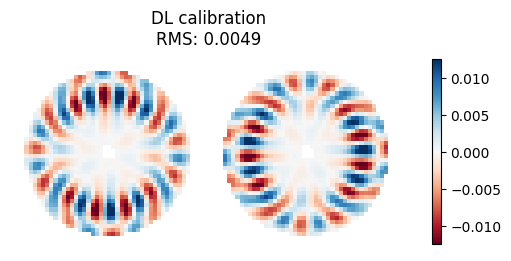

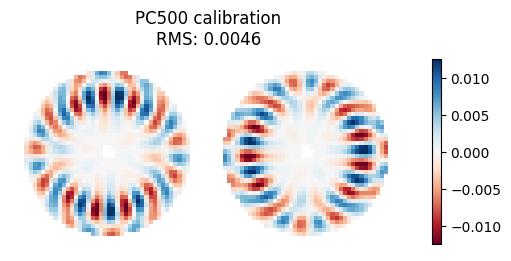

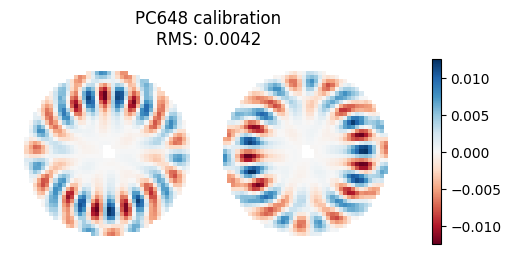

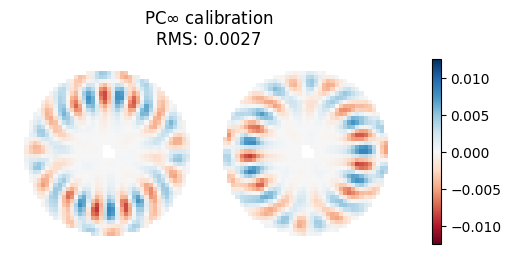

In [ ]:
idx = 100

def normalize(vec):
    normvec = vec - np.mean(vec)
    normvec /= np.std(normvec)
    return normvec
img=show2d_slopes(im[:,idx],title=f'DL calibration\nRMS: {np.std(im[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
# img=show2d_slopes(normalize(im_pc500[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=f'PC500 vs DL calib\nKL {idx}')
# img=show2d_slopes(normalize(im_pc648[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=f'PC648 vs DL calib\nKL {idx}')
# img=show2d_slopes(normalize(im_pcinf[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=r'PC$\infty$'+f' vs DL calib\nKL {idx}')
img=show2d_slopes(im_pc500[:,idx],title=r'PC500 calibration'+f'\nRMS: {np.std(im_pc500[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
img=show2d_slopes(im_pc648[:,idx],title=r'PC648 calibration'+f'\nRMS: {np.std(im_pc648[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
img=show2d_slopes(im_pcinf[:,idx],title=r'PC$\infty$ calibration'+f'\nRMS: {np.std(im_pcinf[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
# img=show2d_slopes(normalize(im_pcinf[:,idx])-normalize(im[:,idx]),title=r'Difference')